In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
df = pd.read_excel(r"C:\Users\bhagr\OneDrive\Documents\Telco_customer_churn\Dataset\Telco_customer_churn.xlsx")

In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
df.shape

(7043, 33)

In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [11]:
df.drop(columns = ['CustomerID'],inplace = True)

In [12]:
drop_cols = [
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

In [13]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [14]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [15]:
df["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [16]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [17]:
df['Total Charges'] = df['Total Charges'].replace(' ',np.nan)

C:\Users\bhagr\AppData\Local\Temp\ipykernel_9792\3903818642.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total Charges'] = df['Total Charges'].replace(' ',np.nan)


In [18]:
df['Total Charges'] = df['Total Charges'].astype(float)

In [19]:
cat_feature = df.select_dtypes(include = 'object').columns

In [20]:
cat_feature

Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label',
       'Churn Reason'],
      dtype='object')

In [21]:
len(cat_feature)

22

In [22]:
for col in cat_feature:
    print("****",col,"*****")
    print()
    print(df[col].value_counts())

**** Country *****

Country
United States    7043
Name: count, dtype: int64
**** State *****

State
California    7043
Name: count, dtype: int64
**** City *****

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64
**** Lat Long *****

Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
41.505916, -120.152505    4
41.764869, -122.671316    4
41.465121, -122.380947    4
40.021787, -122.127576    4
41.737962, -123.07557     4
Name: count, Length: 1652, dtype: int64
**** Gender *****

Gender
Male      3555
Female    3488
Name: count, dtype: int64
**** Senior Citizen *****

Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64
**** Partn

In [23]:
num_features = df.select_dtypes(exclude = 'object').columns

In [24]:
num_features

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')

In [25]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [26]:
df.dtypes

Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [28]:
df["Total Charges"].dtype

dtype('float64')

# Overall churn distribution

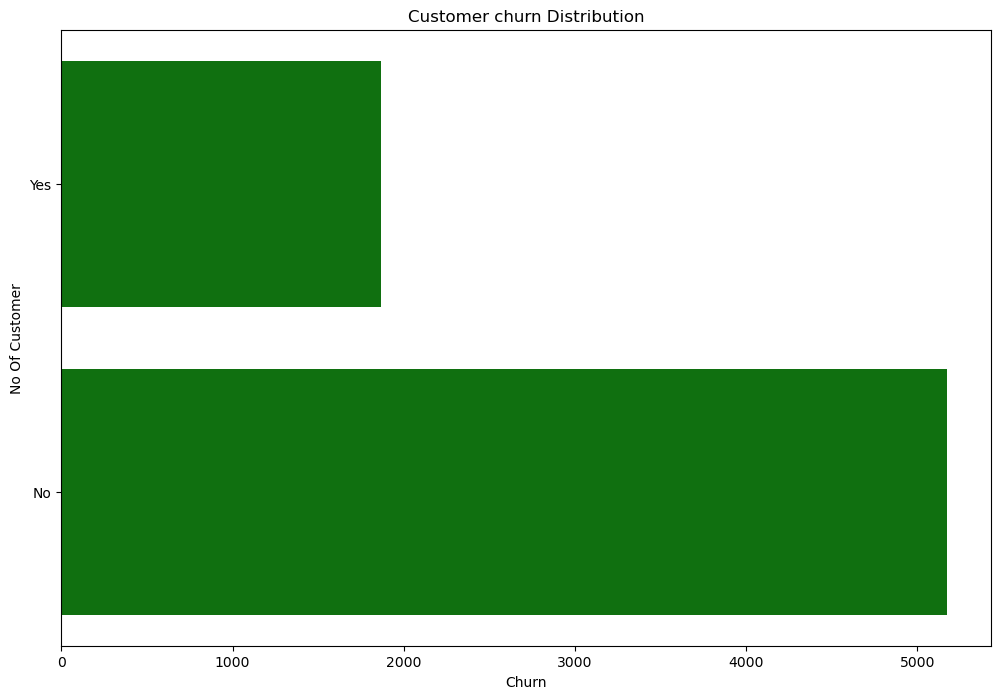

In [29]:
plt.figure(figsize = (12,8))

sns.countplot(df['Churn Label'],color = "green")

plt.title("Customer churn Distribution")
plt.xlabel("Churn")
plt.ylabel("No Of Customer")
plt.show()

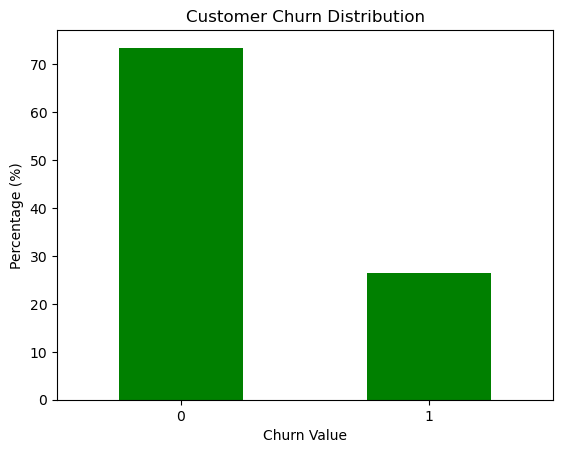

In [30]:
(df['Churn Value'].value_counts(normalize=True) * 100).plot(kind='bar',color = 'green')

plt.xlabel('Churn Value')
plt.ylabel('Percentage (%)')
plt.title('Customer Churn Distribution')
plt.xticks(rotation=0)
plt.show()

# Churn by numerical features

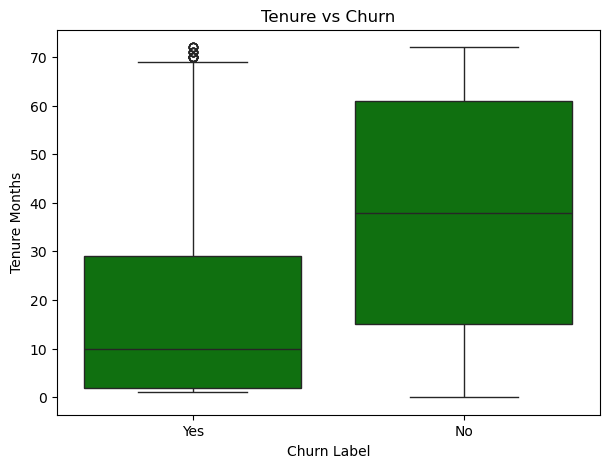

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months",
    color = 'green'
)

plt.title("Tenure vs Churn")
plt.show()

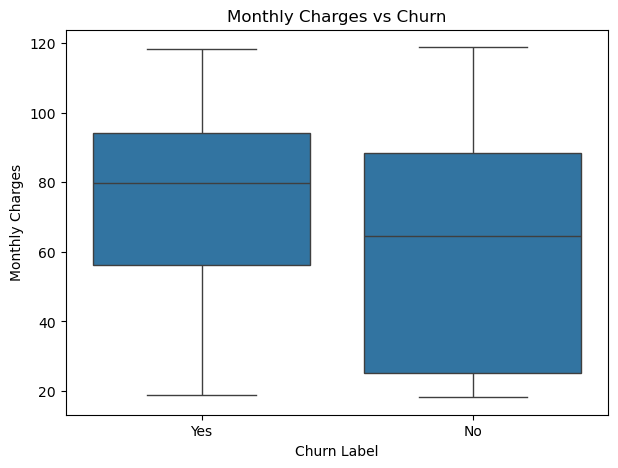

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

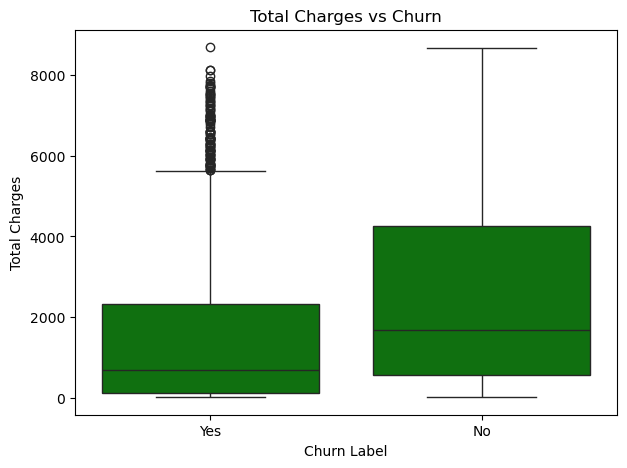

In [33]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges",
    color = 'green'
)

plt.title("Total Charges vs Churn")
plt.show()

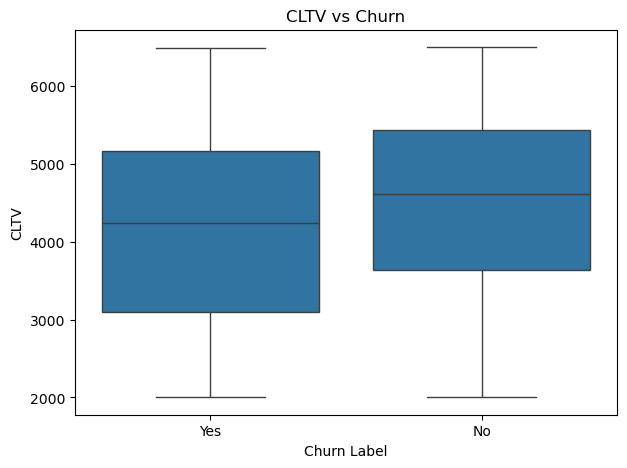

In [34]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)

plt.title("CLTV vs Churn")
plt.show()

# Contract vs Churn

In [35]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


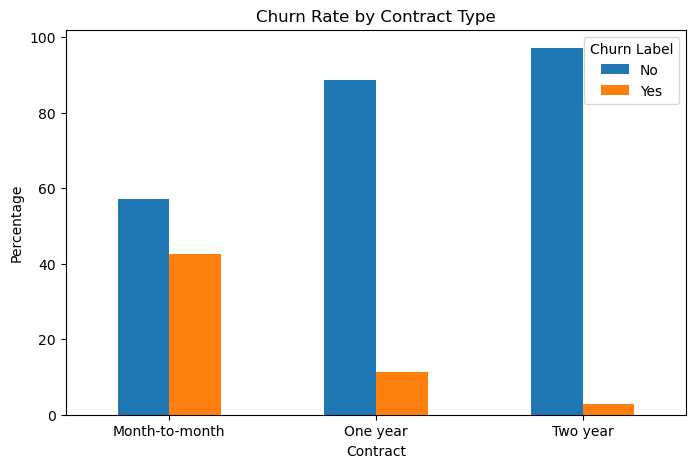

In [36]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

# Churn by Tenure

In [37]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [38]:
tenure_churn = pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-6 Months,46.666667,53.333333
7-12 Months,64.113475,35.886525
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


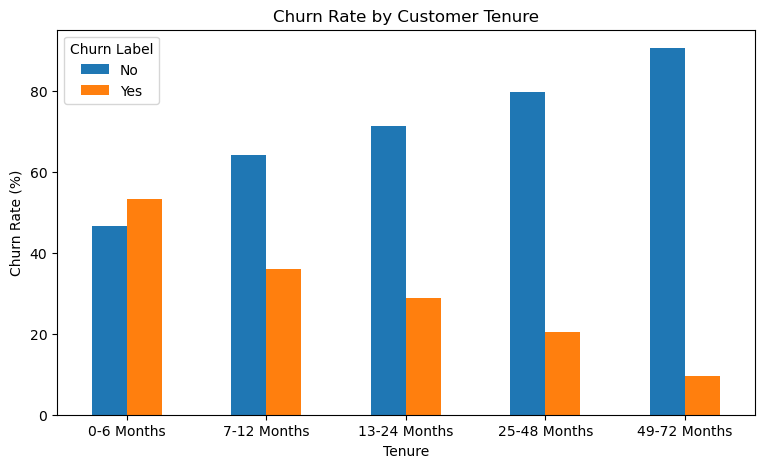

In [39]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure")

plt.xticks(rotation=0)
plt.show()

# Monthly Charges vs Churn

In [40]:
df["Charge Group"] = pd.qcut(
    df["Monthly Charges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [41]:
charge_churn = pd.crosstab(
    df["Charge Group"],
    df["Churn Label"],
    normalize="index"
) * 100

charge_churn

Churn Label,No,Yes
Charge Group,,
Low,88.762770,11.237230
Medium-Low,75.424689,24.575311
Medium-High,62.492886,37.507114
High,67.121729,32.878271


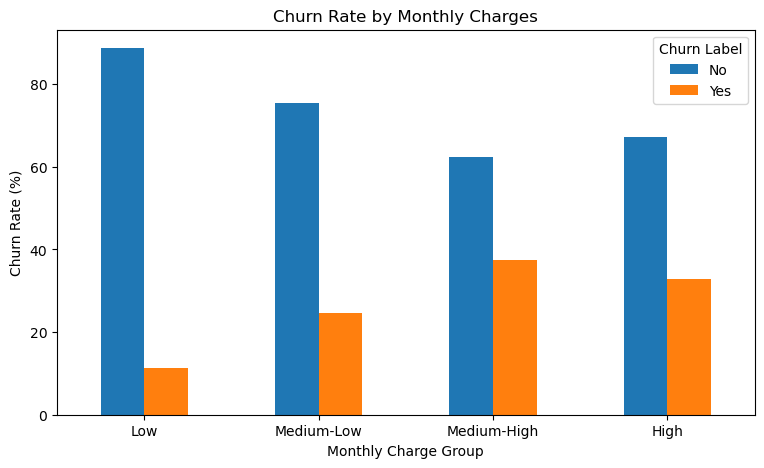

In [42]:
charge_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Monthly Charges")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Monthly Charge Group")

plt.xticks(rotation=0)
plt.show()

# Categorical feature analysis

In [43]:
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [44]:
for col in categorical_features:

    print("\n" + "="*50)
    print(col)

    result = pd.crosstab(
        df[col],
        df["Churn Label"],
        normalize="index"
    ) * 100

    print(result)


Gender
Churn Label         No        Yes
Gender                           
Female       73.079128  26.920872
Male         73.839662  26.160338

Senior Citizen
Churn Label            No        Yes
Senior Citizen                      
No              76.393832  23.606168
Yes             58.318739  41.681261

Partner
Churn Label         No        Yes
Partner                          
No           67.042021  32.957979
Yes          80.335097  19.664903

Dependents
Churn Label         No        Yes
Dependents                       
No           67.448301  32.551699
Yes          93.484942   6.515058

Phone Service
Churn Label           No        Yes
Phone Service                      
No             75.073314  24.926686
Yes            73.290363  26.709637

Multiple Lines
Churn Label              No        Yes
Multiple Lines                        
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

Internet Service
Churn Label

# Most important categorical variables

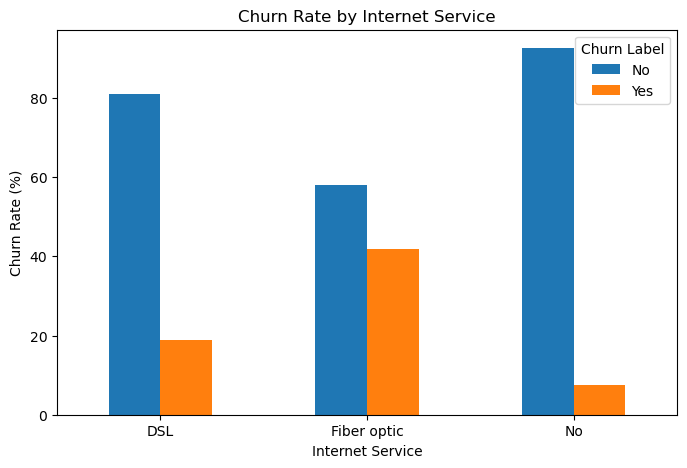

In [45]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")

plt.xticks(rotation=0)
plt.show()

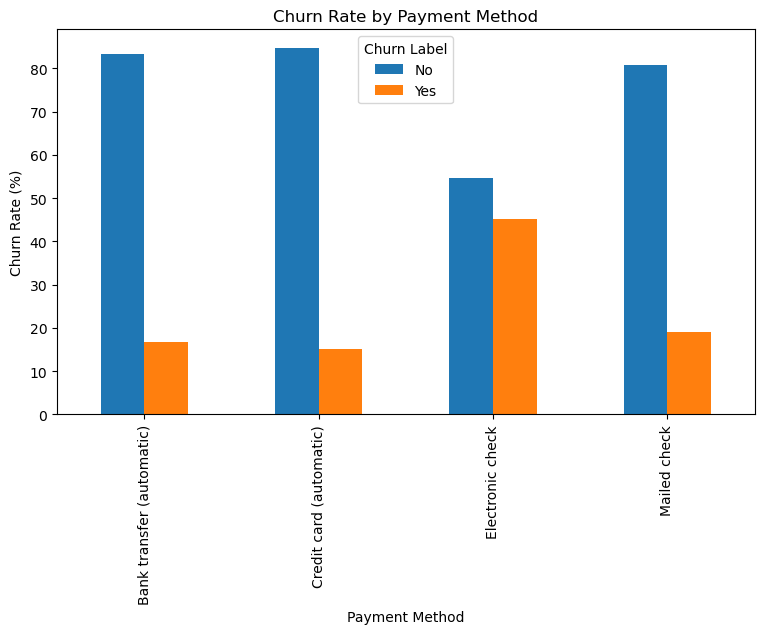

In [46]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")

plt.xticks(rotation=90)
plt.show()

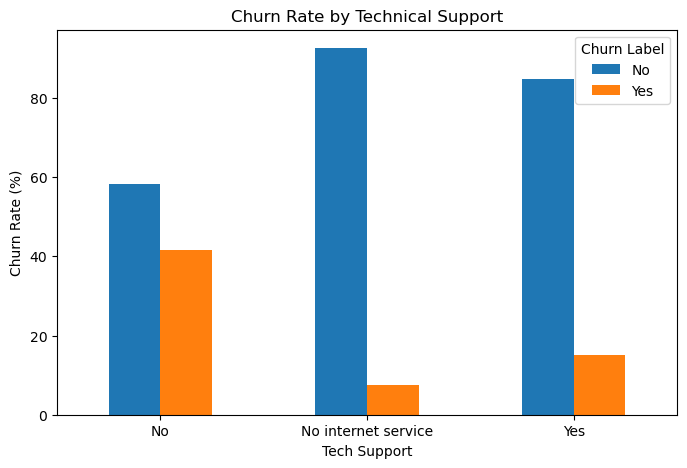

In [47]:
support_churn = pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
) * 100

support_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Technical Support")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.show()

# Correlation analysis

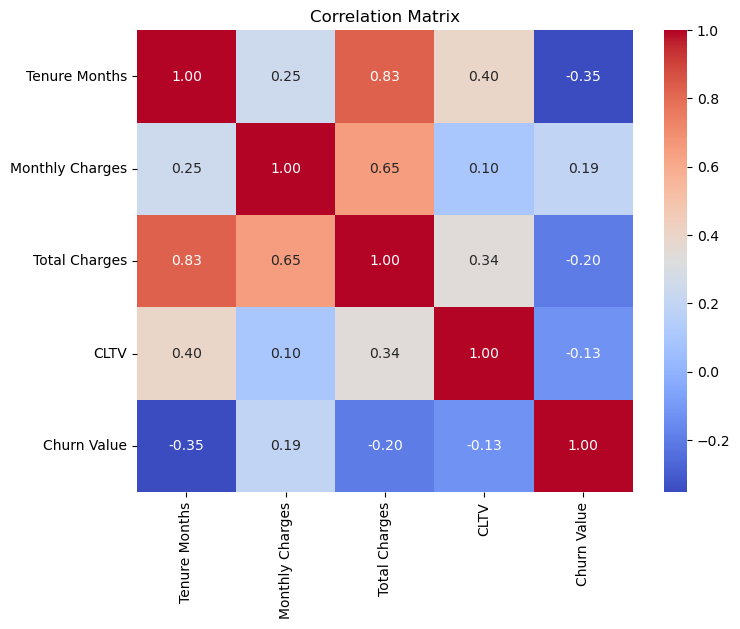

In [48]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Service-level churn analysis

In [49]:
service_features = [
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

for col in service_features:

    result = pd.crosstab(
        df[col],
        df["Churn Label"],
        normalize="index"
    ) * 100

    print("\n", "=" * 60)
    print(col)
    print(result.round(2))


Internet Service
Churn Label          No    Yes
Internet Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No                92.60   7.40

Online Security
Churn Label             No    Yes
Online Security                  
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

Online Backup
Churn Label             No    Yes
Online Backup                    
No                   60.07  39.93
No internet service  92.60   7.40
Yes                  78.47  21.53

Device Protection
Churn Label             No    Yes
Device Protection                
No                   60.87  39.13
No internet service  92.60   7.40
Yes                  77.50  22.50

Tech Support
Churn Label             No    Yes
Tech Support                     
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17

Streaming TV
Churn Label             No    Yes
Streaming TV                     


In [50]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [51]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [52]:
demo_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Paperless Billing"
]

for col in demo_features:

    result = pd.crosstab(
        df[col],
        df["Churn Label"],
        normalize="index"
    ) * 100

    print("\n", "=" * 60)
    print(col)
    print(result.round(2))


Gender
Churn Label     No    Yes
Gender                   
Female       73.08  26.92
Male         73.84  26.16

Senior Citizen
Churn Label        No    Yes
Senior Citizen              
No              76.39  23.61
Yes             58.32  41.68

Partner
Churn Label     No    Yes
Partner                  
No           67.04  32.96
Yes          80.34  19.66

Dependents
Churn Label     No    Yes
Dependents               
No           67.45  32.55
Yes          93.48   6.52

Paperless Billing
Churn Label           No    Yes
Paperless Billing              
No                 83.67  16.33
Yes                66.43  33.57


# Our complete EDA

In [53]:
df_model = df.copy()

In [54]:
df_model

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group,Charge Group
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-6 Months,Medium-Low
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0-6 Months,Medium-High
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,7-12 Months,High
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48 Months,High
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,49-72 Months,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,...,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN,49-72 Months,Low
7039,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,...,Mailed check,84.80,1990.50,No,0,59,2140,NaN,13-24 Months,Medium-High
7040,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,...,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN,49-72 Months,High
7041,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,...,Electronic check,29.60,346.45,No,0,59,2793,NaN,7-12 Months,Low


In [55]:
drop_cols = [
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df_model = df_model.drop(columns=drop_cols)

In [56]:
df_model.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV', 'Tenure Group', 'Charge Group'],
      dtype='object')

In [57]:
df_model.shape

(7043, 23)

In [58]:
y = df_model["Churn Value"]

In [59]:
X = df_model.drop(columns=["Churn Value"])

In [60]:
print(X.shape, y.shape)

(7043, 22) (7043,)


# Preprocessing And Feature Engineering

In [61]:
df_model["Total Charges"] = pd.to_numeric(
    df_model["Total Charges"],
    errors="coerce"
)

In [62]:
df_model["Total Charges"].isna().sum()

np.int64(11)

In [63]:
df_model["Total Charges"] = df_model["Total Charges"].fillna(0)

In [64]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [65]:
print(y.value_counts())

Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [66]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical Features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


# Train Test Split

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing:
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Build the preprocessing pipeline

In [69]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [70]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [72]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [73]:
import numpy as np

print("Training NaN:",
      np.isnan(X_train_processed).sum())

print("Testing NaN:",
      np.isnan(X_test_processed).sum())

Training NaN: 0
Testing NaN: 0


# ML model

In [74]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [75]:
y_pred = log_model.predict(X_test_processed)

y_prob = log_model.predict_proba(X_test_processed)[:, 1]

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7430801987224982
Precision: 0.5104529616724739
Recall   : 0.7834224598930482
F1 Score : 0.6181434599156118
ROC-AUC  : 0.8489291895941512


In [77]:
log_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

# RandomForest 

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight= "balanced",
    n_jobs = -1
)

rf_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [80]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

In [81]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.7785663591199432
Precision: 0.5704545454545454
Recall   : 0.6711229946524064
F1 Score : 0.6167076167076168
ROC-AUC  : 0.8416608540649462


In [82]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

# Gradient Boosting:

In [83]:
from sklearn.ensemble import GradientBoostingClassifier

In [84]:
gb_model = GradientBoostingClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 3,
    random_state = 42
)
gb_model.fit(
    X_train_processed,
    y_train
)

gb_pred = gb_model.predict(X_test_processed)

gb_prob = gb_model.predict_proba(
    X_test_processed
)[:, 1]

In [85]:
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_prob))

Accuracy : 0.7998580553584103
Precision: 0.652317880794702
Recall   : 0.5267379679144385
F1 Score : 0.5828402366863905
ROC-AUC  : 0.849142318323904


In [86]:
gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1 Score": f1_score(y_test, gb_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_prob)
}

In [87]:
comparison = pd.DataFrame([
    log_results,
    rf_results,
    gb_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.743080,0.510453,0.783422,0.618143,0.848929
1,Random Forest,0.778566,0.570455,0.671123,0.616708,0.841661
2,Gradient Boosting,0.799858,0.652318,0.526738,0.582840,0.849142


In [88]:
from xgboost import XGBClassifier

In [89]:
xgb_model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 3,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    eval_metric = "logloss"
)

xgb_model.fit(
    X_train_processed,
    y_train
)


xgb_pred = xgb_model.predict(X_test_processed)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [90]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.8034066713981547
Precision: 0.6549520766773163
Recall   : 0.5481283422459893
F1 Score : 0.5967976710334789
ROC-AUC  : 0.8534720607610633


In [91]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

In [92]:
comparison = pd.DataFrame([
    log_results,
    rf_results,
    gb_results,
    xgb_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.743080,0.510453,0.783422,0.618143,0.848929
1,Random Forest,0.778566,0.570455,0.671123,0.616708,0.841661
2,Gradient Boosting,0.799858,0.652318,0.526738,0.582840,0.849142
3,XGBoost,0.803407,0.654952,0.548128,0.596798,0.853472


# LGBMClassifier

In [93]:
from lightgbm import LGBMClassifier

In [94]:
lgb_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 3,
    num_leaves = 15,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    verbosity = -1
)

lgb_model.fit(
    X_train_processed,
    y_train
)


lgb_pred = lgb_model.predict(X_test_processed)

lgb_prob = lgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [95]:
print("Accuracy :", accuracy_score(y_test, lgb_pred))
print("Precision:", precision_score(y_test, lgb_pred))
print("Recall   :", recall_score(y_test, lgb_pred))
print("F1 Score :", f1_score(y_test, lgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lgb_prob))

Accuracy : 0.8041163946061036
Precision: 0.6644295302013423
Recall   : 0.5294117647058824
F1 Score : 0.5892857142857143
ROC-AUC  : 0.8529269678886048


In [96]:
lgb_results = {
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_test, lgb_pred),
    "Precision": precision_score(y_test, lgb_pred),
    "Recall": recall_score(y_test, lgb_pred),
    "F1 Score": f1_score(y_test, lgb_pred),
    "ROC-AUC": roc_auc_score(y_test, lgb_prob)
}

In [97]:
comparison = pd.DataFrame([
    log_results,
    rf_results,
    gb_results,
    xgb_results,
    lgb_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.743080,0.510453,0.783422,0.618143,0.848929
1,Random Forest,0.778566,0.570455,0.671123,0.616708,0.841661
2,Gradient Boosting,0.799858,0.652318,0.526738,0.582840,0.849142
3,XGBoost,0.803407,0.654952,0.548128,0.596798,0.853472
4,LightGBM,0.804116,0.664430,0.529412,0.589286,0.852927


In [98]:
thresholds = np.arange(0.20, 0.71, 0.05)

for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.20 | Precision: 0.404 | Recall: 0.971 | F1: 0.571
Threshold: 0.25 | Precision: 0.419 | Recall: 0.930 | F1: 0.578
Threshold: 0.30 | Precision: 0.437 | Recall: 0.909 | F1: 0.590
Threshold: 0.35 | Precision: 0.455 | Recall: 0.890 | F1: 0.602
Threshold: 0.40 | Precision: 0.479 | Recall: 0.872 | F1: 0.618
Threshold: 0.45 | Precision: 0.498 | Recall: 0.824 | F1: 0.620
Threshold: 0.50 | Precision: 0.510 | Recall: 0.783 | F1: 0.618
Threshold: 0.55 | Precision: 0.530 | Recall: 0.746 | F1: 0.620
Threshold: 0.60 | Precision: 0.562 | Recall: 0.719 | F1: 0.631
Threshold: 0.65 | Precision: 0.583 | Recall: 0.679 | F1: 0.627
Threshold: 0.70 | Precision: 0.607 | Recall: 0.620 | F1: 0.614


In [99]:
best_threshold = 0.60

final_pred = (y_prob >= best_threshold).astype(int)

In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



In [101]:
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))

Precision: 0.5615866388308977
Recall: 0.7192513368983957
F1 Score: 0.6307151230949589


# Tuning for LogisticRegression

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [103]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear", "lbfgs"]
}

In [104]:
grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [105]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Recall:")
print(grid.best_score_)

Best Parameters:
{'model__C': 100, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}

Best CV Recall:
0.8120401337792641


In [106]:
best_log_model = grid.best_estimator_

y_pred_tuned = best_log_model.predict(X_test)
y_prob_tuned = best_log_model.predict_proba(X_test)[:, 1]

In [107]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_tuned))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_tuned))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8477098349221112


In [108]:
results = {
    "Logistic Regression": [
        0.7431, 0.5105, 0.7834, 0.6181, 0.8489
    ],
    "Random Forest": [
        0.7786, 0.5705, 0.6711, 0.6167, 0.8417
    ],
    "Gradient Boosting": [
        0.7999, 0.6523, 0.5267, 0.5828, 0.8491
    ],
    "XGBoost": [
        0.8034, 0.6550, 0.5481, 0.5968, 0.8535
    ],
    "LightGBM": [
        0.8041, 0.6644, 0.5294, 0.5893, 0.8529
    ]
}

comparison_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).T

comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7431,0.5105,0.7834,0.6181,0.8489
Random Forest,0.7786,0.5705,0.6711,0.6167,0.8417
Gradient Boosting,0.7999,0.6523,0.5267,0.5828,0.8491
XGBoost,0.8034,0.6550,0.5481,0.5968,0.8535
LightGBM,0.8041,0.6644,0.5294,0.5893,0.8529


# Tuning for XGBoosting

In [109]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 3, 5, 10]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train_processed, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [110]:
print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random.best_score_)

Best XGBoost Parameters:
{'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}

Best CV ROC-AUC:
0.8649623059345837


In [111]:
best_xgb = xgb_random.best_estimator_

xgb_tuned_pred = best_xgb.predict(X_test_processed)
xgb_tuned_prob = best_xgb.predict_proba(X_test_processed)[:, 1]

In [112]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, xgb_tuned_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_tuned_prob))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8553191764189206


# Tuning for LGBMClassifier

In [113]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 3, 5, 7, 10],
    "num_leaves": [7, 15, 31, 50, 70],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [0, 1, 5, 10]
}

In [114]:
lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgb_random.fit(X_train_processed, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 3, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functio

In [115]:
print("Best LightGBM Parameters:")
print(lgb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(lgb_random.best_score_)

Best LightGBM Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'num_leaves': 7, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV ROC-AUC:
0.8643995519552398


In [116]:
best_lgb = lgb_random.best_estimator_

lgb_tuned_pred = best_lgb.predict(X_test_processed)
lgb_tuned_prob = best_lgb.predict_proba(X_test_processed)[:, 1]

In [117]:
print(classification_report(y_test, lgb_tuned_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lgb_tuned_prob))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8542160737812913


In [118]:
tuned_results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ],

    "XGBoost": [
        accuracy_score(y_test, xgb_tuned_pred),
        precision_score(y_test, xgb_tuned_pred),
        recall_score(y_test, xgb_tuned_pred),
        f1_score(y_test, xgb_tuned_pred),
        roc_auc_score(y_test, xgb_tuned_prob)
    ],

    "LightGBM": [
        accuracy_score(y_test, lgb_tuned_pred),
        precision_score(y_test, lgb_tuned_pred),
        recall_score(y_test, lgb_tuned_pred),
        f1_score(y_test, lgb_tuned_pred),
        roc_auc_score(y_test, lgb_tuned_prob)
    ]
}

comparison_tuned = pd.DataFrame(
    tuned_results,
    index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).T

comparison_tuned

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.743790,0.511344,0.783422,0.618796,0.847710
XGBoost,0.799858,0.650327,0.532086,0.585294,0.855319
LightGBM,0.804116,0.661184,0.537433,0.592920,0.854216


In [119]:
thresholds = np.arange(0.20, 0.71, 0.05)

for threshold in thresholds:

    pred = (xgb_tuned_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.20 | Precision: 0.481 | Recall: 0.864 | F1: 0.618
Threshold: 0.25 | Precision: 0.513 | Recall: 0.821 | F1: 0.632
Threshold: 0.30 | Precision: 0.536 | Recall: 0.789 | F1: 0.639
Threshold: 0.35 | Precision: 0.571 | Recall: 0.727 | F1: 0.640
Threshold: 0.40 | Precision: 0.595 | Recall: 0.679 | F1: 0.634
Threshold: 0.45 | Precision: 0.636 | Recall: 0.602 | F1: 0.618
Threshold: 0.50 | Precision: 0.650 | Recall: 0.532 | F1: 0.585
Threshold: 0.55 | Precision: 0.711 | Recall: 0.460 | F1: 0.558
Threshold: 0.60 | Precision: 0.726 | Recall: 0.369 | F1: 0.489
Threshold: 0.65 | Precision: 0.768 | Recall: 0.291 | F1: 0.422
Threshold: 0.70 | Precision: 0.807 | Recall: 0.235 | F1: 0.364


In [120]:
xgb_threshold = 0.35

xgb_final_pred = (
    xgb_tuned_prob >= xgb_threshold
).astype(int)

In [121]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_final_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.73      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



In [122]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.71, 0.05)

for threshold in thresholds:

    pred = (lgb_tuned_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.20 | Precision: 0.476 | Recall: 0.866 | F1: 0.615
Threshold: 0.25 | Precision: 0.507 | Recall: 0.832 | F1: 0.630
Threshold: 0.30 | Precision: 0.532 | Recall: 0.789 | F1: 0.635
Threshold: 0.35 | Precision: 0.557 | Recall: 0.741 | F1: 0.636
Threshold: 0.40 | Precision: 0.582 | Recall: 0.666 | F1: 0.621
Threshold: 0.45 | Precision: 0.626 | Recall: 0.610 | F1: 0.618
Threshold: 0.50 | Precision: 0.661 | Recall: 0.537 | F1: 0.593
Threshold: 0.55 | Precision: 0.707 | Recall: 0.465 | F1: 0.561
Threshold: 0.60 | Precision: 0.728 | Recall: 0.358 | F1: 0.480
Threshold: 0.65 | Precision: 0.772 | Recall: 0.281 | F1: 0.412
Threshold: 0.70 | Precision: 0.804 | Recall: 0.198 | F1: 0.318


In [123]:
lgb_threshold = 0.35

lgb_final_pred = (
    lgb_tuned_prob >= lgb_threshold
).astype(int)

In [124]:
print(classification_report(y_test, lgb_final_pred))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



# Final Model

In [125]:
xgb_threshold = 0.35

xgb_final_pred = (
    xgb_tuned_prob >= xgb_threshold
).astype(int)

In [126]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_final_pred
))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.73      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



In [127]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(y_test, xgb_final_pred)
final_precision = precision_score(y_test, xgb_final_pred)
final_recall = recall_score(y_test, xgb_final_pred)
final_f1 = f1_score(y_test, xgb_final_pred)
final_auc = roc_auc_score(y_test, xgb_tuned_prob)

print("Final XGBoost Model")
print("-------------------")
print("Threshold :", xgb_threshold)
print("Accuracy  :", round(final_accuracy, 4))
print("Precision :", round(final_precision, 4))
print("Recall    :", round(final_recall, 4))
print("F1 Score  :", round(final_f1, 4))
print("ROC-AUC   :", round(final_auc, 4))

Final XGBoost Model
-------------------
Threshold : 0.35
Accuracy  : 0.7828
Precision : 0.5714
Recall    : 0.7273
F1 Score  : 0.64
ROC-AUC   : 0.8553


In [128]:
final_model = best_xgb

In [129]:
import joblib

joblib.dump(final_model, "xgboost_churn_model.pkl")
joblib.dump(preprocessor, "churn_preprocessor.pkl")

['churn_preprocessor.pkl']

In [130]:
joblib.dump(xgb_threshold, "churn_threshold.pkl")

['churn_threshold.pkl']

# XGBoost Feature Importance

In [131]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 31
['num__Tenure Months' 'num__Monthly Charges' 'num__Total Charges'
 'num__CLTV' 'cat__Gender_Male' 'cat__Senior Citizen_Yes'
 'cat__Partner_Yes' 'cat__Dependents_Yes' 'cat__Phone Service_Yes'
 'cat__Multiple Lines_No phone service' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_Fiber optic' 'cat__Internet Service_No'
 'cat__Online Security_No internet service' 'cat__Online Security_Yes'
 'cat__Online Backup_No internet service' 'cat__Online Backup_Yes'
 'cat__Device Protection_No internet service' 'cat__Device Protection_Yes'
 'cat__Tech Support_No internet service']


In [132]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
29,cat__Payment Method_Electronic check,0.182779
26,cat__Contract_Two year,0.171956
11,cat__Internet Service_Fiber optic,0.130734
25,cat__Contract_One year,0.099222
13,cat__Online Security_No internet service,0.065058
15,cat__Online Backup_No internet service,0.063077
7,cat__Dependents_Yes,0.059257
12,cat__Internet Service_No,0.046346
0,num__Tenure Months,0.037860
27,cat__Paperless Billing_Yes,0.025619


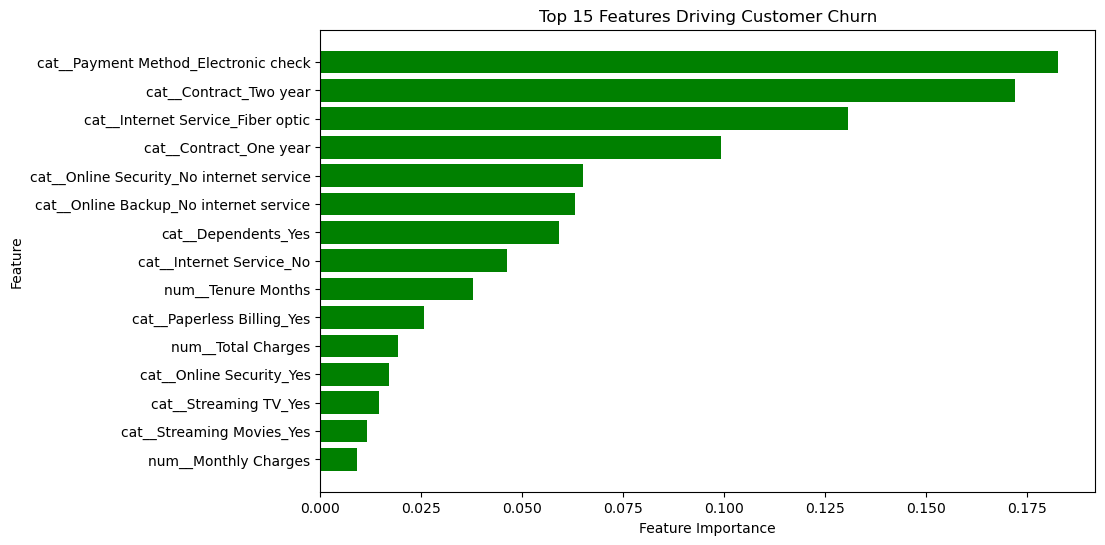

In [133]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color = 'green'
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Customer Churn")

plt.show()

In [134]:
import shap
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_processed)

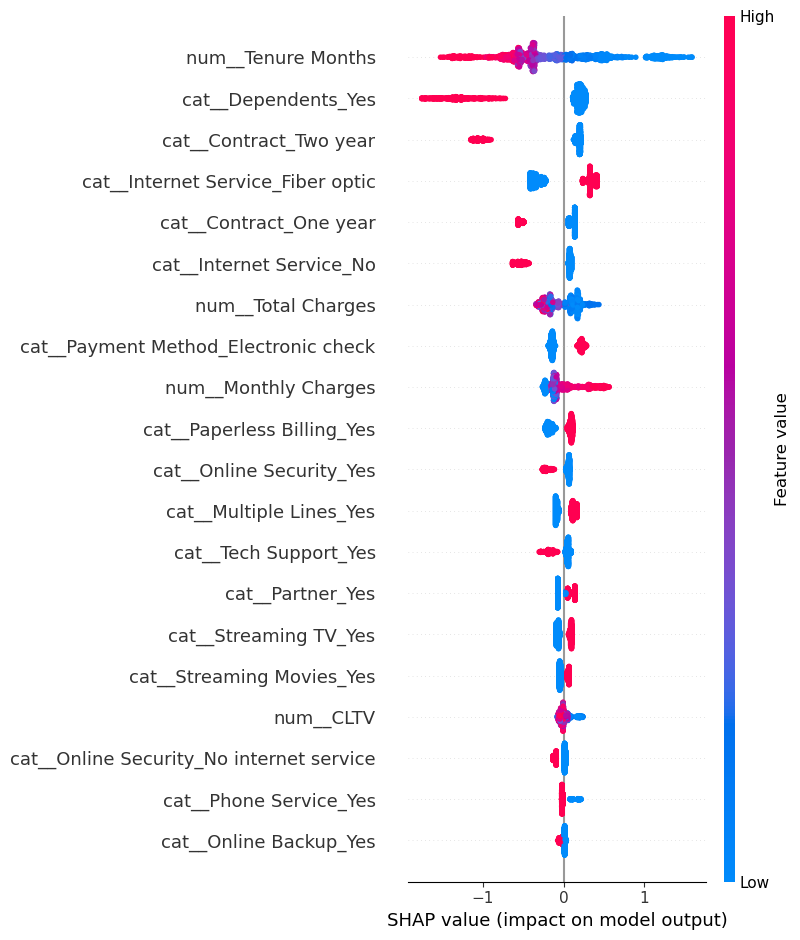

In [135]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

# Customer Risk Scoring

In [136]:
customer_risk = X_test.copy()

customer_risk["Churn_Probability"] = xgb_tuned_prob

customer_risk["Risk"] = pd.cut(
    customer_risk["Churn_Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

customer_risk[
    ["Churn_Probability", "Risk"]
].head(10)

,Churn_Probability,Risk
2196,0.066222,Low
3549,0.761241,High
3515,0.150581,Low
5162,0.480625,Medium
4642,0.029817,Low
6096,0.631827,High
4504,0.466847,Medium
4067,0.061139,Low
6233,0.003488,Low
430,0.317756,Medium


# Add a retention recommendation

In [138]:
def retention_recommendation(row):

    probability = row["Churn_Probability"]
    risk = row["Risk"]

    if risk == "Very High":
        return "Immediate retention call + personalized offer"

    elif risk == "High":
        return "Targeted retention offer + customer support follow-up"

    elif risk == "Medium":
        return "Monitor customer + engagement campaign"

    else:
        return "No immediate action"


customer_risk["Recommendation"] = customer_risk.apply(
    retention_recommendation,
    axis=1
)

In [139]:
customer_risk[
    ["Churn_Probability", "Risk", "Recommendation"]
].head(20)

,Churn_Probability,Risk,Recommendation
2196,0.066222,Low,No immediate action
3549,0.761241,High,Targeted retention offer + customer support fo...
3515,0.150581,Low,No immediate action
5162,0.480625,Medium,Monitor customer + engagement campaign
4642,0.029817,Low,No immediate action
6096,0.631827,High,Targeted retention offer + customer support fo...
4504,0.466847,Medium,Monitor customer + engagement campaign
4067,0.061139,Low,No immediate action
6233,0.003488,Low,No immediate action
430,0.317756,Medium,Monitor customer + engagement campaign


In [140]:
risk_summary = customer_risk["Risk"].value_counts().sort_index()

risk_summary

Risk
Low          859
Medium       360
High         145
Very High     45
Name: count, dtype: int64

In [141]:
risk_percentage = (
    customer_risk["Risk"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

risk_percentage.round(2)

Risk
Low          60.97
Medium       25.55
High         10.29
Very High     3.19
Name: proportion, dtype: float64

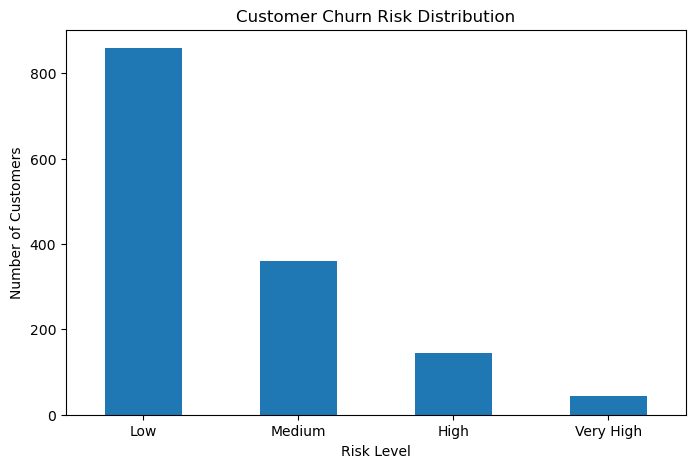

In [142]:
risk_summary.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Churn Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# recommendation function

In [143]:
def retention_recommendation(row):

    recommendations = []

    # Risk-based action
    if row["Risk"] == "Very High":
        recommendations.append(
            "Immediate retention call"
        )

    elif row["Risk"] == "High":
        recommendations.append(
            "Targeted retention offer"
        )

    elif row["Risk"] == "Medium":
        recommendations.append(
            "Engagement campaign"
        )

    else:
        recommendations.append(
            "No immediate action"
        )

    # Customer-specific actions
    if row["Tenure Months"] <= 6:
        recommendations.append(
            "New-customer onboarding support"
        )

    if row["Monthly Charges"] >= 70:
        recommendations.append(
            "Review pricing / offer suitable plan"
        )

    if row["Payment Method"] == "Electronic check":
        recommendations.append(
            "Encourage automatic payment"
        )

    if row["Tech Support"] == "No":
        recommendations.append(
            "Offer technical support"
        )

    if row["Online Security"] == "No":
        recommendations.append(
            "Offer online security service"
        )

    if row["Contract"] == "Month-to-month":
        recommendations.append(
            "Offer longer-term contract"
        )

    return " | ".join(recommendations)

In [144]:
customer_risk["Recommendation"] = customer_risk.apply(
    retention_recommendation,
    axis=1
)

In [145]:
customer_risk.sort_values(
    "Churn_Probability",
    ascending=False
)[[
    "Churn_Probability",
    "Risk",
    "Contract",
    "Tenure Months",
    "Monthly Charges",
    "Payment Method",
    "Tech Support",
    "Online Security",
    "Recommendation"
]].head(20)

,Churn_Probability,Risk,Contract,Tenure Months,Monthly Charges,Payment Method,Tech Support,Online Security,Recommendation
886,0.927152,Very High,Month-to-month,1,95.10,Electronic check,No,No,Immediate retention call | New-customer onboar...
590,0.920593,Very High,Month-to-month,1,102.45,Electronic check,No,Yes,Immediate retention call | New-customer onboar...
1818,0.909051,Very High,Month-to-month,1,95.45,Electronic check,No,No,Immediate retention call | New-customer onboar...
158,0.882142,Very High,Month-to-month,1,89.55,Electronic check,No,No,Immediate retention call | New-customer onboar...
598,0.881004,Very High,Month-to-month,1,74.50,Electronic check,No,No,Immediate retention call | New-customer onboar...
1681,0.875279,Very High,Month-to-month,7,101.95,Electronic check,No,No,Immediate retention call | Review pricing / of...
684,0.875279,Very High,Month-to-month,7,99.25,Electronic check,No,No,Immediate retention call | Review pricing / of...
1044,0.872845,Very High,Month-to-month,6,105.30,Electronic check,No,No,Immediate retention call | New-customer onboar...
1827,0.870454,Very High,Month-to-month,3,105.90,Electronic check,No,No,Immediate retention call | New-customer onboar...
1756,0.868562,Very High,Month-to-month,1,76.45,Electronic check,No,No,Immediate retention call | New-customer onboar...


In [146]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(best_xgb, "xgboost_churn_model.pkl")
joblib.dump(0.35, "churn_threshold.pkl")

['churn_threshold.pkl']

# Create the retention table

In [147]:
retention_df = customer_risk.copy()

retention_df["Churn_Probability"] = (
    retention_df["Churn_Probability"] * 100
).round(2)

retention_df = retention_df.sort_values(
    "Churn_Probability",
    ascending=False
)

retention_df.head(20)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Tenure Group,Charge Group,Churn_Probability,Risk,Recommendation
886,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,95.10,95.10,5795,0-6 Months,High,92.720001,Very High,Immediate retention call | New-customer onboar...
590,Female,No,Yes,No,1,Yes,Yes,Fiber optic,Yes,No,...,Yes,Electronic check,102.45,102.45,4811,0-6 Months,High,92.059998,Very High,Immediate retention call | New-customer onboar...
1818,Male,No,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,95.45,95.45,5962,0-6 Months,High,90.910004,Very High,Immediate retention call | New-customer onboar...
158,Male,No,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,89.55,89.55,4996,0-6 Months,Medium-High,88.209999,Very High,Immediate retention call | New-customer onboar...
598,Male,No,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,74.50,74.50,5554,0-6 Months,Medium-High,88.099998,Very High,Immediate retention call | New-customer onboar...
1681,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,101.95,700.85,2016,7-12 Months,High,87.529999,Very High,Immediate retention call | Review pricing / of...
684,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,99.25,665.45,2487,7-12 Months,High,87.529999,Very High,Immediate retention call | Review pricing / of...
1044,Female,No,Yes,No,6,Yes,Yes,Fiber optic,No,Yes,...,Yes,Electronic check,105.30,545.20,4163,0-6 Months,High,87.279999,Very High,Immediate retention call | New-customer onboar...
1827,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Electronic check,105.90,334.65,2715,0-6 Months,High,87.050003,Very High,Immediate retention call | New-customer onboar...
1756,Male,Yes,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,76.45,76.45,3763,0-6 Months,Medium-High,86.860001,Very High,Immediate retention call | New-customer onboar...


# Select the important columns

In [148]:
retention_df = retention_df[
    [
        "Churn_Probability",
        "Risk",
        "Tenure Months",
        "Contract",
        "Internet Service",
        "Monthly Charges",
        "Payment Method",
        "Online Security",
        "Tech Support",
        "Dependents",
        "Recommendation"
    ]
]

In [149]:
retention_df.head(20)

,Churn_Probability,Risk,Tenure Months,Contract,Internet Service,Monthly Charges,Payment Method,Online Security,Tech Support,Dependents,Recommendation
886,92.720001,Very High,1,Month-to-month,Fiber optic,95.10,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
590,92.059998,Very High,1,Month-to-month,Fiber optic,102.45,Electronic check,Yes,No,No,Immediate retention call | New-customer onboar...
1818,90.910004,Very High,1,Month-to-month,Fiber optic,95.45,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
158,88.209999,Very High,1,Month-to-month,Fiber optic,89.55,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
598,88.099998,Very High,1,Month-to-month,Fiber optic,74.50,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1681,87.529999,Very High,7,Month-to-month,Fiber optic,101.95,Electronic check,No,No,No,Immediate retention call | Review pricing / of...
684,87.529999,Very High,7,Month-to-month,Fiber optic,99.25,Electronic check,No,No,No,Immediate retention call | Review pricing / of...
1044,87.279999,Very High,6,Month-to-month,Fiber optic,105.30,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1827,87.050003,Very High,3,Month-to-month,Fiber optic,105.90,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1756,86.860001,Very High,1,Month-to-month,Fiber optic,76.45,Electronic check,No,No,No,Immediate retention call | New-customer onboar...


In [150]:
action_required = retention_df[
    retention_df["Risk"].isin(["High", "Very High"])
]

action_required.head(20)

,Churn_Probability,Risk,Tenure Months,Contract,Internet Service,Monthly Charges,Payment Method,Online Security,Tech Support,Dependents,Recommendation
886,92.720001,Very High,1,Month-to-month,Fiber optic,95.10,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
590,92.059998,Very High,1,Month-to-month,Fiber optic,102.45,Electronic check,Yes,No,No,Immediate retention call | New-customer onboar...
1818,90.910004,Very High,1,Month-to-month,Fiber optic,95.45,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
158,88.209999,Very High,1,Month-to-month,Fiber optic,89.55,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
598,88.099998,Very High,1,Month-to-month,Fiber optic,74.50,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1681,87.529999,Very High,7,Month-to-month,Fiber optic,101.95,Electronic check,No,No,No,Immediate retention call | Review pricing / of...
684,87.529999,Very High,7,Month-to-month,Fiber optic,99.25,Electronic check,No,No,No,Immediate retention call | Review pricing / of...
1044,87.279999,Very High,6,Month-to-month,Fiber optic,105.30,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1827,87.050003,Very High,3,Month-to-month,Fiber optic,105.90,Electronic check,No,No,No,Immediate retention call | New-customer onboar...
1756,86.860001,Very High,1,Month-to-month,Fiber optic,76.45,Electronic check,No,No,No,Immediate retention call | New-customer onboar...


In [151]:
print("Customers requiring retention action:",
      len(action_required))

Customers requiring retention action: 190


In [152]:
action_required.to_csv(
    "high_risk_customers.csv",
    index=False
)

In [153]:
import joblib

joblib.dump(best_xgb, "xgboost_churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(0.35, "churn_threshold.pkl")

['churn_threshold.pkl']

In [154]:
import joblib

joblib.dump(best_xgb, "xgboost_churn_model.pkl")
joblib.dump(preprocessor, "churn_preprocessor.pkl")
joblib.dump(xgb_threshold, "churn_threshold.pkl")

['churn_threshold.pkl']

In [155]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\bhagr\OneDrive\Documents\Telco_customer_churn\Notebooks
['.ipynb_checkpoints', '01_eda.ipynb', 'anaconda_projects', 'churn_preprocessor.pkl', 'churn_threshold.pkl', 'high_risk_customers.csv', 'preprocessor.pkl', 'xgboost_churn_model.pkl']
